In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
smote_xgb_model = joblib.load(
    '../models/smote_xgb_model.pkl'
)

In [3]:
smote_xgb_model

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The

In [4]:
type(smote_xgb_model)

imblearn.pipeline.Pipeline

In [5]:
smote_xgb_model.named_steps.keys()

dict_keys(['preprocessor', 'smote', 'model'])

In [6]:
xgb_model = smote_xgb_model.named_steps['model']

In [7]:
importance = xgb_model.feature_importances_

In [8]:
feature_names = (
    smote_xgb_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

In [9]:
len(feature_names)

17

In [10]:
len(importance)

17

In [11]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
4,num__annual_expenditure_inr,0.328404
11,cat__state_tier_Tier-3,0.200271
3,num__family_members,0.054246
6,num__savings,0.051459
5,num__expense_ratio,0.035848
13,cat__occupation_class_Medium-Risk,0.035491
1,num__total_income_inr,0.035129
12,cat__occupation_class_Low-Risk,0.034418
8,num__expenditure_per_member,0.033502
10,cat__state_tier_Tier-2,0.032529


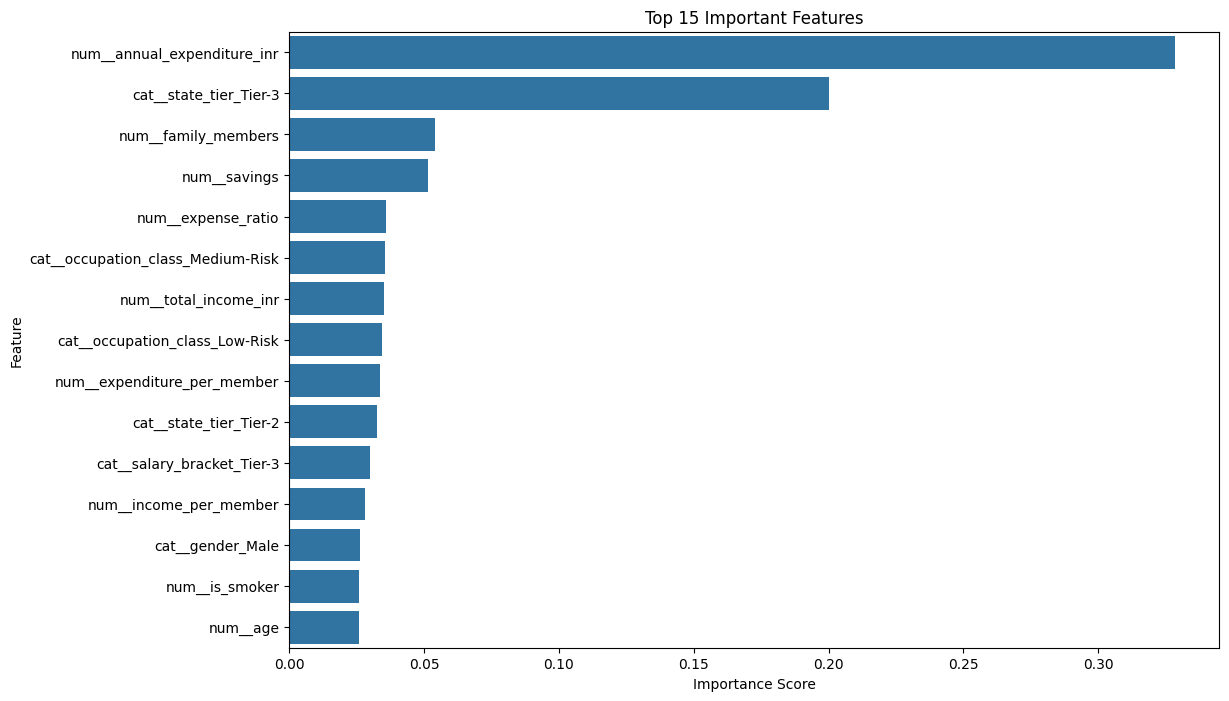

In [12]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

This tells us that the model is learning customer spending patterns rather than simply relying on age or smoking.

# Business Interpretation

## Annual Expenditure is the biggest driver.

Business Meaning:

Customers who spend more annually are more likely to choose higher medical plans.

Why?

Higher expenditure generally indicates:

- higher purchasing power,
- better financial capability,
- willingness to pay for comprehensive healthcare.

## Tier-3 State is the second most important feature.

This is actually an interesting business insight.

Possible reasons:

- Different healthcare accessibility.
- Different insurance awareness.
- Different income distributions.
- Different medical costs and plan preferences.

This would make the insurance company investigate regional customer behaviour further.

## Family Members matter.

Larger families generally need:

- broader coverage,
- family floater plans,
- higher sum insured.

This aligns with business intuition.

## Savings and Expense Ratio matter.

Customers with:

- higher savings,
- better financial planning,
- can afford better plans.

In [13]:
feature_importance['Cumulative_Importance'] = (
    feature_importance['Importance'].cumsum()
)

feature_importance

,Feature,Importance,Cumulative_Importance
4,num__annual_expenditure_inr,0.328404,0.328404
11,cat__state_tier_Tier-3,0.200271,0.528675
3,num__family_members,0.054246,0.582921
6,num__savings,0.051459,0.634380
5,num__expense_ratio,0.035848,0.670228
13,cat__occupation_class_Medium-Risk,0.035491,0.705719
1,num__total_income_inr,0.035129,0.740848
12,cat__occupation_class_Low-Risk,0.034418,0.775266
8,num__expenditure_per_member,0.033502,0.808768
10,cat__state_tier_Tier-2,0.032529,0.841296


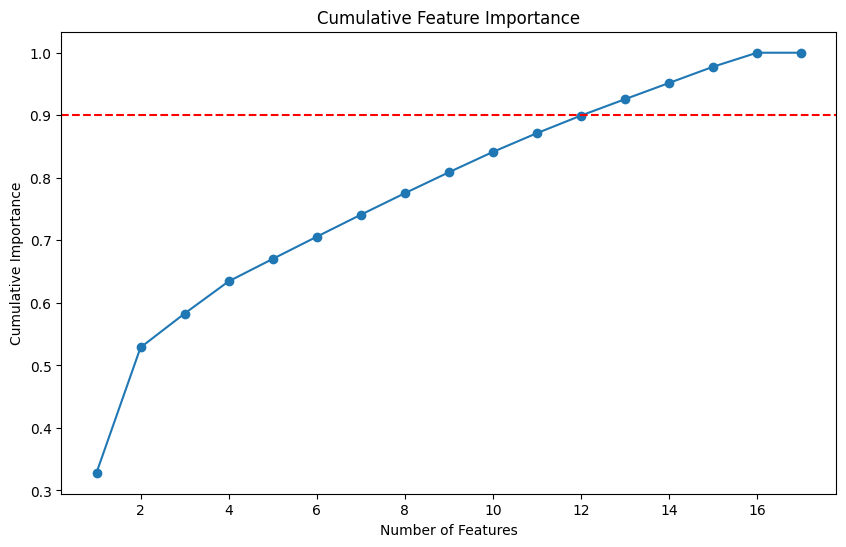

In [14]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(feature_importance)+1),
    feature_importance['Cumulative_Importance'],
    marker='o'
)

plt.axhline(y=0.90, color='red', linestyle='--')

plt.xlabel('Number of Features')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Feature Importance')

plt.show()

## Key Findings

- The top 12 features contribute nearly 90% of the model's predictive power.
- Financial behaviour features are more predictive than demographic variables.
- Annual expenditure and state tier alone explain more than half of the model's predictions.
- Feature reduction was not performed because the feature space was already small and interpretability was a business requirement.
- PCA was intentionally avoided to preserve explainability.

# SHAP (SHapley Additive exPlanations)

Feature Importance tells us:

 - What features matter globally.

SHAP tells us:

- How each feature pushes a prediction toward a class.

In [15]:
import shap

c:\Users\kadit\MedicalPlan-Xray\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1. Load the test data:

In [16]:
X_test_xgb = joblib.load('../models/X_test_xgb.pkl')

2. Get the trained XGBoost model

In [17]:
xgb_model = smote_xgb_model.named_steps['model']

3. Get the preprocessor

In [18]:
preprocessor = smote_xgb_model.named_steps['preprocessor']

4. Transform the test data # Your XGBoost model was trained on transformed features.

In [19]:
X_test_transformed = preprocessor.transform(X_test_xgb)

5. Get transformed feature names:

In [20]:
feature_names = preprocessor.get_feature_names_out()

6. Create SHAP Explainer:

In [21]:
explainer = shap.TreeExplainer(xgb_model)

7. Calculate SHAP values:

In [22]:
shap_values = explainer.shap_values(X_test_transformed)

In [23]:
type(shap_values)

numpy.ndarray

In [26]:
np.array(shap_values).shape

(196, 17, 3)

8. Defining class names:

In [27]:
class_names = ['Low Plan', 'Medium Plan', 'High Plan']

9. Global SHAP Summary Plots:

9.1 Class 0 (Low Plan):

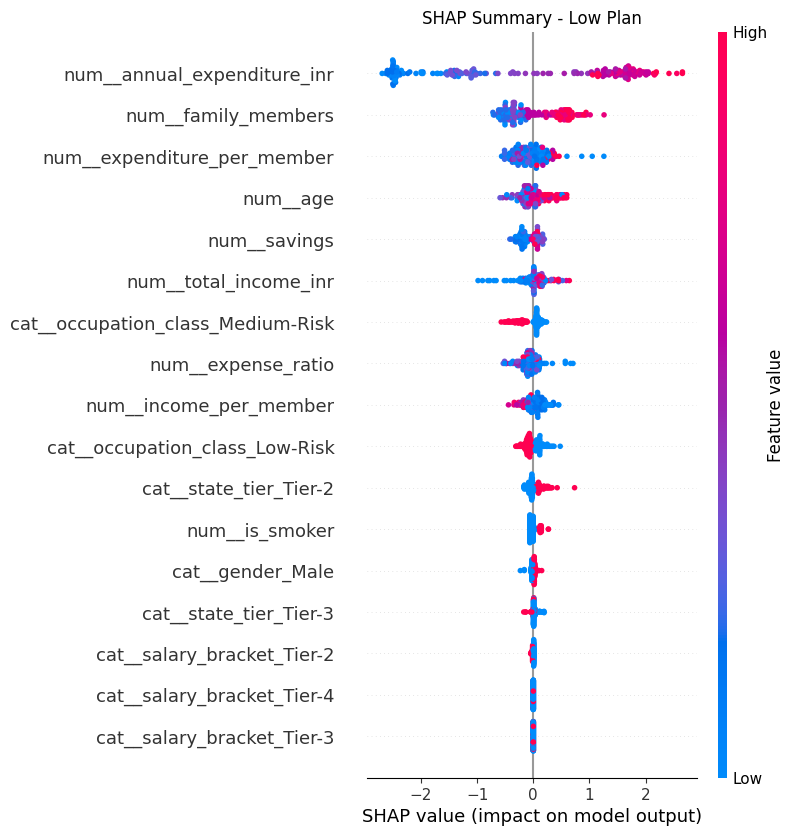

In [ ]:
shap.summary_plot(
    shap_values[:, :, 0],
    X_test_transformed,
    feature_names=feature_names,
    show=False
)

plt.title('SHAP Summary - Low Plan')
plt.show()

9.2 Class 1 (Medium Plan):

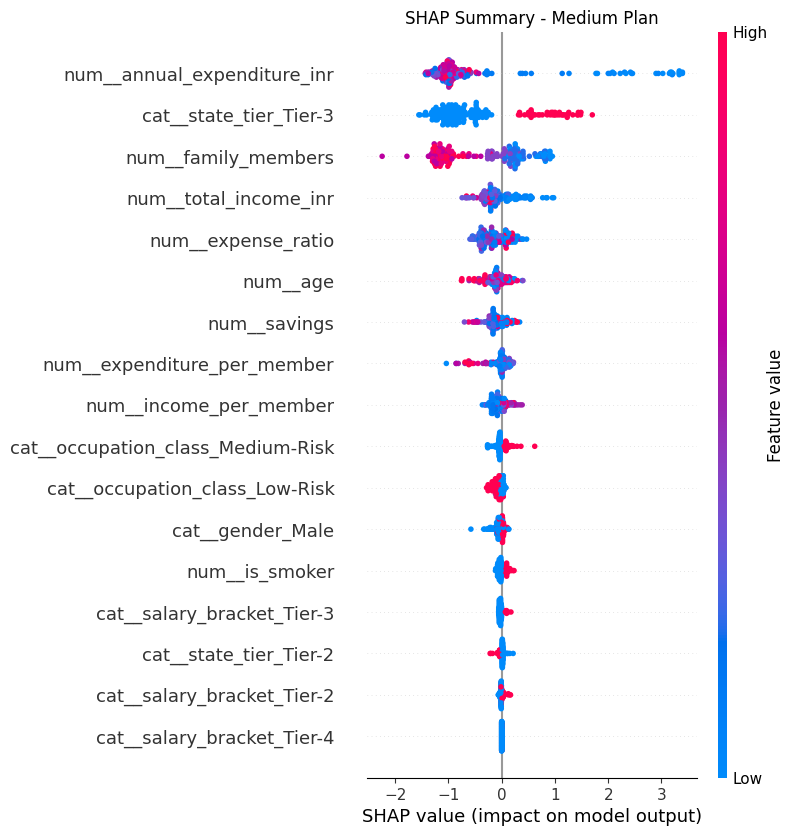

In [30]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_transformed,
    feature_names=feature_names,
    show=False
)

plt.title('SHAP Summary - Medium Plan')
plt.show()

9.3 Class 2 (High Plan):

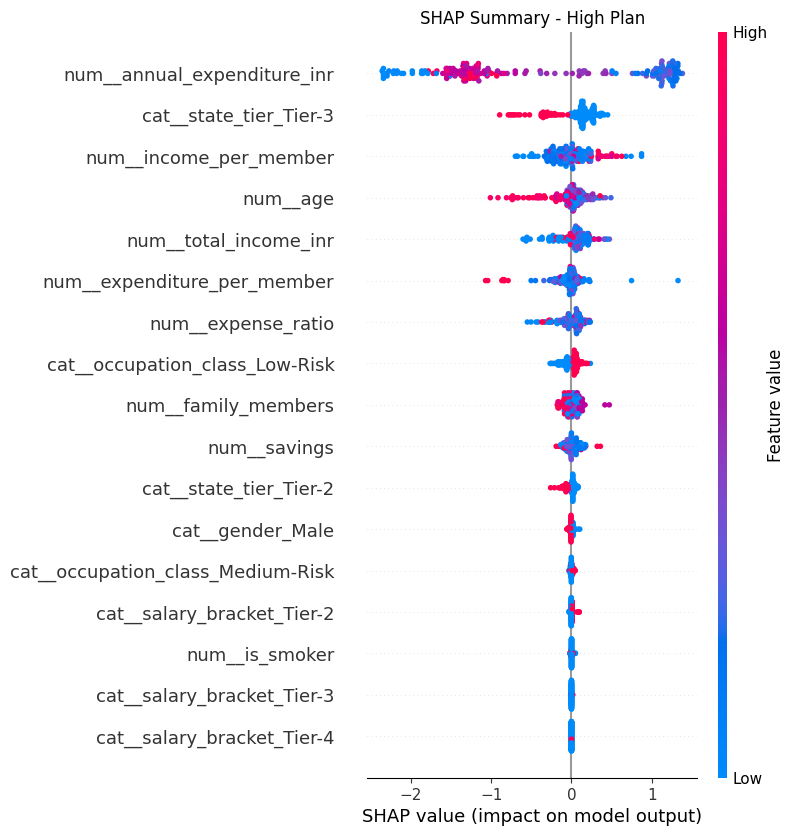

In [29]:
shap.summary_plot(
    shap_values[:, :, 2],
    X_test_transformed,
    feature_names=feature_names,
    show=False
)

plt.title('SHAP Summary - High Plan')
plt.show()

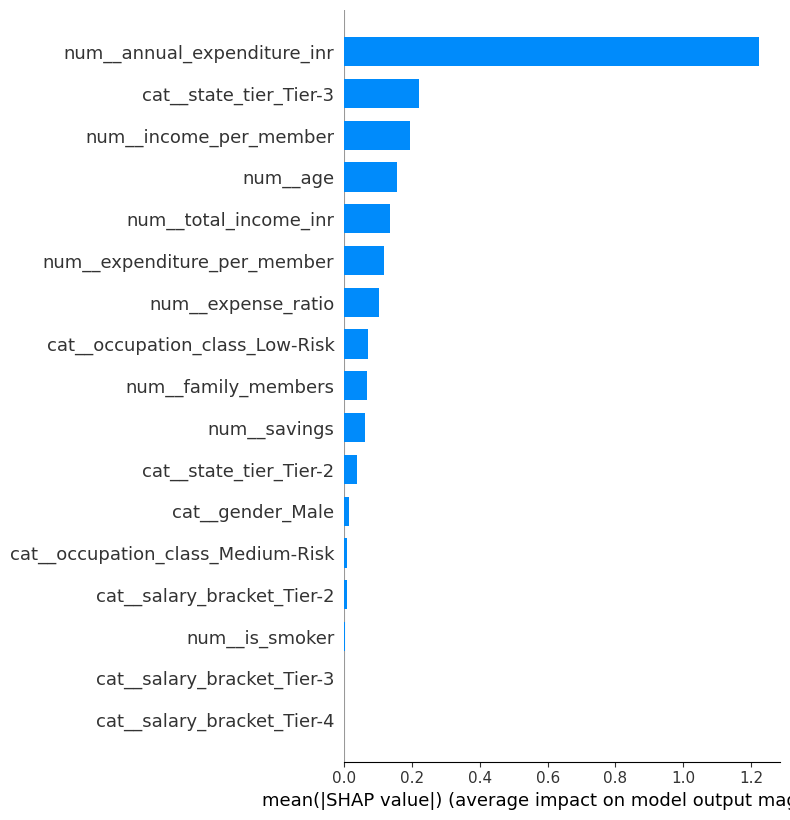

In [32]:
shap.summary_plot(
    shap_values[:, :, 2],
    X_test_transformed,
    feature_names=feature_names,
    plot_type='bar'
)

Dependence plot:

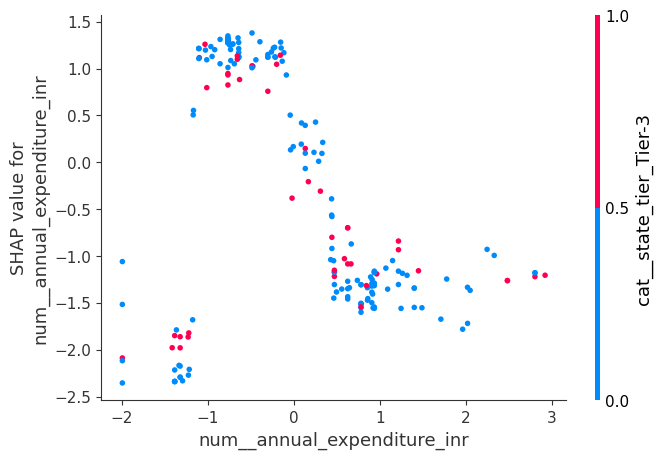

In [33]:
shap.dependence_plot(
    'num__annual_expenditure_inr',
    shap_values[:, :, 2],
    X_test_transformed,
    feature_names=feature_names
)

## SHAP Conclusions

1. Financial variables are the primary drivers of medical plan selection.

2. Annual expenditure is the most influential feature, but its effect is non-linear.

3. Moderate expenditure levels tend to increase the probability of selecting High Plans, while very low and extremely high expenditure levels reduce it.

4. State tier interacts with annual expenditure and influences plan selection behaviour.

5. Demographic variables such as age, gender, and smoking contribute less than financial behaviour.

6. SHAP confirmed that the model learns complex interactions rather than simple linear relationships.